# Lecture 10B — Notebook 10B.5: Auditory Motivations Beyond Mel (PLP-lite + Loudness + Compression)

**Purpose:** Demonstrate two key auditory steps often used in PLP/RASTA-PLP: equal-loudness weighting + power-law (cube-root) compression, and compare features to MFCC.


In [1]:
import os, json, math, re
from pathlib import Path

import numpy as np
import scipy.signal as sig
import scipy.fft as fft
import matplotlib.pyplot as plt

# Optional audio playback
try:
    from IPython.display import Audio, display
    HAS_IPY_AUDIO = True
except Exception:
    HAS_IPY_AUDIO = False

# Optional recording
try:
    import sounddevice as sd
    HAS_SD = True
except Exception as e:
    HAS_SD = False
    print("sounddevice not available (recording disabled).", e)

# ---------- Project paths ----------
PROJECT_ROOT = Path.cwd() / "EE519_L10B_Project"
REC_DIR = PROJECT_ROOT / "recordings"
FIG_DIR = PROJECT_ROOT / "figures"
RES_DIR = PROJECT_ROOT / "results"
MANIFEST_PATH = PROJECT_ROOT / "manifest.json"

for d in [REC_DIR, FIG_DIR, RES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

def load_manifest(path=MANIFEST_PATH):
    if path.exists():
        return json.loads(path.read_text())
    return {"course":"EE519","lecture":"10B","created_utc":None,"clips":[]}

def save_manifest(manifest, path=MANIFEST_PATH):
    if manifest.get("created_utc") is None:
        manifest["created_utc"] = str(np.datetime64("now"))
    path.write_text(json.dumps(manifest, indent=2))
    print("Saved manifest:", path)

def save_fig(fig, name, dpi=150):
    out = FIG_DIR / name
    fig.savefig(out, dpi=dpi, bbox_inches="tight")
    print("Saved figure:", out)
    return out

# ---------- WAV I/O ----------
import wave
def write_wav(path: Path, x: np.ndarray, fs: int):
    x = np.asarray(x, dtype=np.float32)
    x = np.clip(x, -1.0, 1.0)
    x_i16 = (x * 32767.0).astype(np.int16)
    with wave.open(str(path), "wb") as wf:
        wf.setnchannels(1)
        wf.setsampwidth(2)
        wf.setframerate(fs)
        wf.writeframes(x_i16.tobytes())

def read_wav(path: Path):
    with wave.open(str(path), "rb") as wf:
        fs = wf.getframerate()
        n = wf.getnframes()
        x = np.frombuffer(wf.readframes(n), dtype=np.int16).astype(np.float32) / 32768.0
    return fs, x

def peak_normalize(x, target=0.98):
    m = np.max(np.abs(x)) + 1e-12
    return (x / m) * target

def play_audio(x, fs, label="audio"):
    if not HAS_IPY_AUDIO:
        print("(Audio playback not available)", label)
        return
    display(Audio(x, rate=fs))

def record_clip(seconds=2.0, fs=16000):
    if not HAS_SD:
        raise RuntimeError("sounddevice not available. Load wav files instead.")
    print(f"Recording {seconds:.1f}s @ {fs} Hz ...")
    x = sd.rec(int(seconds*fs), samplerate=fs, channels=1, dtype="float32")
    sd.wait()
    return fs, x.squeeze()

def add_clip_to_manifest(filename, label, fs, notes=""):
    clip = {
        "filename": filename,
        "label": label,
        "fs": int(fs),
        "notes": notes,
        "added_utc": str(np.datetime64("now")),
        "selections": {}
    }
    manifest["clips"].append(clip)
    save_manifest(manifest)
    return len(manifest["clips"]) - 1

def list_clips():
    for i,c in enumerate(manifest["clips"]):
        print(f"[{i}] {c['label']:14s}  {c['filename']}  fs={c['fs']}  notes={c.get('notes','')}")

# ---------- Selection + framing helpers ----------
def seconds_to_samples(t0, t1, fs, xlen):
    s0 = int(max(0, round(t0*fs)))
    s1 = int(min(xlen, round(t1*fs)))
    if s1 <= s0:
        raise ValueError("Bad selection: t1 must be > t0")
    return s0, s1

def samples_to_frame_range(s0, s1, N, H, xlen):
    f0 = max(0, int((s0 - N)//H) + 1)
    f1 = min(int((s1)//H), int((xlen-N)//H))
    if f1 < f0:
        f0 = max(0, int(s0//H))
        f1 = min(int((xlen-N)//H), f0)
    return f0, f1

def frame_signal(x, N, H):
    if len(x) < N:
        x = np.pad(x, (0, N-len(x)))
    num = 1 + (len(x) - N)//H
    idx = np.arange(N)[None,:] + H*np.arange(num)[:,None]
    return x[idx]

def db(x):
    return 20*np.log10(np.maximum(x, 1e-12))

# ---------- Auditory scale helpers ----------
def hz_to_mel(hz):
    return 2595.0 * np.log10(1.0 + hz/700.0)

def mel_to_hz(mel):
    return 700.0 * (10**(mel/2595.0) - 1.0)

def mel_filterbank(fs, nfft, n_mels=26, fmin=0.0, fmax=None):
    if fmax is None:
        fmax = fs/2
    # mel points
    mmin, mmax = hz_to_mel(fmin), hz_to_mel(fmax)
    m_pts = np.linspace(mmin, mmax, n_mels+2)
    hz_pts = mel_to_hz(m_pts)
    # fft bin frequencies
    freqs = np.linspace(0, fs/2, nfft//2 + 1)
    bins = np.floor((nfft+1) * hz_pts / fs).astype(int)
    fb = np.zeros((n_mels, len(freqs)), dtype=np.float64)
    for i in range(n_mels):
        b0, b1, b2 = bins[i], bins[i+1], bins[i+2]
        b0 = np.clip(b0, 0, len(freqs)-1)
        b1 = np.clip(b1, 0, len(freqs)-1)
        b2 = np.clip(b2, 0, len(freqs)-1)
        if b1 == b0: b1 += 1
        if b2 == b1: b2 += 1
        # rising
        fb[i, b0:b1] = (np.arange(b0, b1) - b0) / (b1 - b0 + 1e-12)
        # falling
        fb[i, b1:b2] = (b2 - np.arange(b1, b2)) / (b2 - b1 + 1e-12)
    return fb, freqs, hz_pts

manifest = load_manifest()
print("Project root:", PROJECT_ROOT)
print("Clips in manifest:", len(manifest["clips"]))


Project root: c:\Users\K\Documents\usc\ee519\ee519-lecture\lecture10b\EE519_L10B_Project
Clips in manifest: 12


## 1) Choose clip + selection


In [3]:
list_clips()
CLIP_IDX = 0
segment_name = "vowel_mid"

clip = manifest["clips"][CLIP_IDX]
fs, x = read_wav(REC_DIR/clip["filename"])
x = peak_normalize(x)
sel = clip["selections"]["analysis_segments"][segment_name]

N = sel["N"]; H = sel["H"]
xseg = x[sel["s0"]:sel["s1"]]

window = sig.windows.hann(N, sym=False)
frames = frame_signal(xseg, N, H)
NFFT = 2048 if fs <= 16000 else 4096
X = fft.rfft(frames * window[None,:], n=NFFT, axis=1)
P = (np.abs(X)**2) / NFFT  # (T, F)
freqs = np.linspace(0, fs/2, P.shape[1])
print("P:", P.shape)


[0] vowel_a         student10B_vowel_a.wav  fs=16000  notes=steady /a/
[1] vowel_i         student10B_vowel_i.wav  fs=16000  notes=steady /i/
[2] fricative_s     student10B_fricative_s.wav  fs=16000  notes=steady /s/
[3] sentence        student10B_sentence.wav  fs=16000  notes=short sentence
[4] vowel_a         student10B_vowel_a.wav  fs=16000  notes=steady /a/
[5] vowel_i         student10B_vowel_i.wav  fs=16000  notes=steady /i/
[6] fricative_s     student10B_fricative_s.wav  fs=16000  notes=steady /s/
[7] sentence        student10B_sentence.wav  fs=16000  notes=short sentence
[8] vowel_a         student10B_vowel_a.wav  fs=16000  notes=steady /a/
[9] vowel_i         student10B_vowel_i.wav  fs=16000  notes=steady /i/
[10] fricative_s     student10B_fricative_s.wav  fs=16000  notes=steady /s/
[11] sentence        student10B_sentence.wav  fs=16000  notes=short sentence
P: (48, 1025)


## 2) Equal-loudness weighting (simple model)

We use a simplified equal-loudness curve (teaching version).
It boosts mid frequencies and de-emphasizes very low/high frequencies.

**Note:** This is a pedagogical approximation; full PLP has more detail.


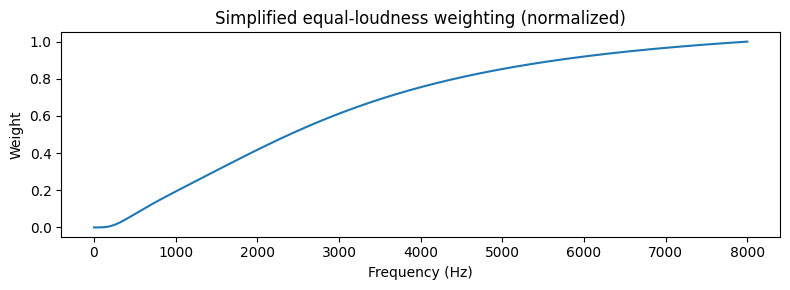

Saved figure: c:\Users\K\Documents\usc\ee519\ee519-lecture\lecture10b\EE519_L10B_Project\figures\L10B_equal_loudness_curve.png


WindowsPath('c:/Users/K/Documents/usc/ee519/ee519-lecture/lecture10b/EE519_L10B_Project/figures/L10B_equal_loudness_curve.png')

In [4]:
# Simple equal-loudness weighting (approx)
# Avoid zeros at DC
f = np.maximum(freqs, 1.0)
# One common approximation form (not exact ISO): emphasize ~1-4 kHz
E = ((f**2) / (f**2 + 1.6e5))**2 * ((f**2 + 1.44e6) / (f**2 + 9.61e6))
E = E / np.max(E)

fig = plt.figure(figsize=(8,3))
plt.plot(freqs, E)
plt.title("Simplified equal-loudness weighting (normalized)")
plt.xlabel("Frequency (Hz)"); plt.ylabel("Weight")
plt.tight_layout(); plt.show()
save_fig(fig, "L10B_equal_loudness_curve.png")


## 3) Apply weighting + power-law compression

Two steps:
1) Weighted spectrum: P_w = P * E
2) Compression: P_c = (P_w)^(1/3)  (cube-root, loudness-like)

Then project into mel (or any filterbank) and compare log vs cube-root.


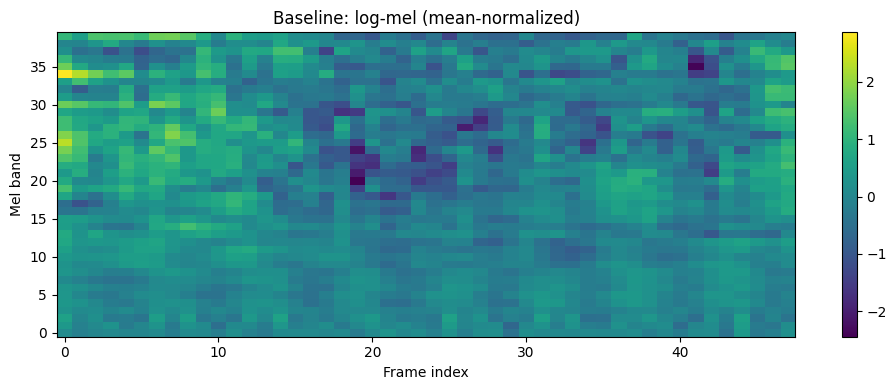

Saved figure: c:\Users\K\Documents\usc\ee519\ee519-lecture\lecture10b\EE519_L10B_Project\figures\L10B_logmel_mean_norm_clip0_vowel_mid.png


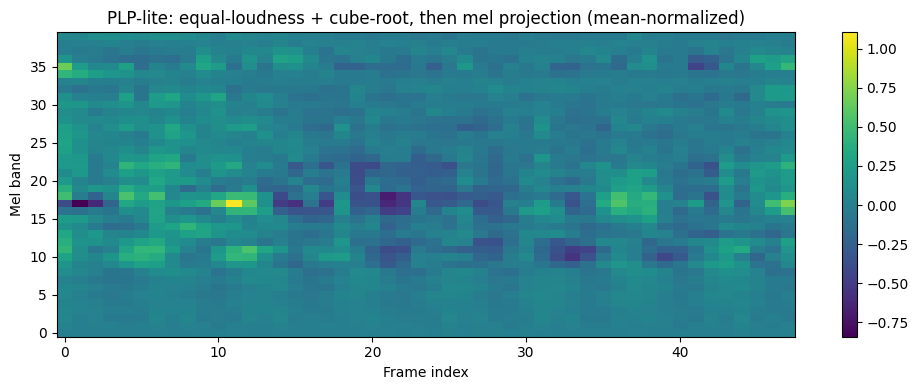

Saved figure: c:\Users\K\Documents\usc\ee519\ee519-lecture\lecture10b\EE519_L10B_Project\figures\L10B_plplite_mel_mean_norm_clip0_vowel_mid.png


WindowsPath('c:/Users/K/Documents/usc/ee519/ee519-lecture/lecture10b/EE519_L10B_Project/figures/L10B_plplite_mel_mean_norm_clip0_vowel_mid.png')

In [5]:
P_w = P * E[None,:]
P_c = np.power(np.maximum(P_w, 1e-12), 1/3)

n_mels = 40
fb, _, _ = mel_filterbank(fs, NFFT, n_mels=n_mels)
M_log = np.log(P @ fb.T + 1e-12)            # baseline log-mel
M_plp = (P_c @ fb.T)                         # loudness-like (already compressed)

# Normalize for display
M_log_n = M_log - np.mean(M_log, axis=0, keepdims=True)
M_plp_n = M_plp - np.mean(M_plp, axis=0, keepdims=True)

fig = plt.figure(figsize=(10,4))
plt.imshow(M_log_n.T, origin="lower", aspect="auto")
plt.title("Baseline: log-mel (mean-normalized)")
plt.xlabel("Frame index"); plt.ylabel("Mel band")
plt.colorbar()
plt.tight_layout(); plt.show()
save_fig(fig, f"L10B_logmel_mean_norm_clip{CLIP_IDX}_{re.sub(r'[^a-zA-Z0-9_]+','_',segment_name)}.png")

fig = plt.figure(figsize=(10,4))
plt.imshow(M_plp_n.T, origin="lower", aspect="auto")
plt.title("PLP-lite: equal-loudness + cube-root, then mel projection (mean-normalized)")
plt.xlabel("Frame index"); plt.ylabel("Mel band")
plt.colorbar()
plt.tight_layout(); plt.show()
save_fig(fig, f"L10B_plplite_mel_mean_norm_clip{CLIP_IDX}_{re.sub(r'[^a-zA-Z0-9_]+','_',segment_name)}.png")


## Wrap-up
**What you learned:** auditory-inspired weighting + compression changes feature emphasis versus plain log-mel.  


## Reflection
1) Which representation (log-mel vs PLP-lite) seems more robust to overall gain changes? Why?  
2) How might equal-loudness weighting help speech tasks?  
3) What information might it suppress that could still be useful?


### Answers

1. PLP-lite is generally more robust to overall gain changes because of the perceptual weighting.
2. Equal-loudness weighting can help speech tasks by putting more weight on the regions of frequencies that humans perceive.
3. It may supress low frequency energy or overall loudness which could be used in speaker recognition.